In [6]:
import pandas as pd

df = pd.read_csv("./data/raw/orders.csv")
df.head(100)

,order_id,customer_id,order_timestamp,product_name,category,quantity,unit_price,discount_pct,final_amount,shipping_cost,payment_method,order_status,delivery_days,rating,is_returned,device_type
0,ORD000000001,CUST0050000,2020-12-19 10:15:00,Non-stick Pan,Home & Kitchen,1,3000,0,3000.0,0.0,Debit Card,Returned,NaN,NaN,1,App (iOS)
1,ORD000000002,CUST0049993,2021-03-28 04:21:00,Kurta,Fashion,1,2060,20,1648.0,0.0,Debit Card,Delivered,2.0,4.0,0,Mobile
2,ORD000000003,CUST0050000,2022-08-16 21:24:00,Sneakers,Fashion,2,1600,20,2560.0,0.0,Cash on Delivery,Delivered,5.0,4.0,0,App (iOS)
3,ORD000000004,CUST0049999,2022-01-24 07:31:00,Foundation,Beauty,1,1500,10,1350.0,0.0,Credit Card,Delivered,6.0,NaN,0,App (Android)
4,ORD000000005,CUST0049396,2024-08-01 11:46:00,Refined Oil 1L,Grocery,1,320,0,320.0,29.0,UPI,Cancelled,NaN,NaN,0,App (Android)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD000000096,CUST0049999,2021-01-20 10:17:00,Phone Case,Electronics,1,4130,5,3923.5,0.0,Credit Card,Failed,NaN,NaN,0,App (iOS)
96,ORD000000097,CUST0049987,2024-09-29 20:22:00,Wireless Earbuds,Electronics,1,6460,0,6460.0,0.0,UPI,Delivered,2.0,4.0,0,App (iOS)
97,ORD000000098,CUST0049281,2023-03-22 15:26:00,Wallet,Fashion,1,1010,70,303.0,49.0,Credit Card,Delivered,3.0,1.0,0,Desktop
98,ORD000000099,CUST0049658,2024-07-23 17:09:00,LED Lamp,Home & Kitchen,1,1690,30,1183.0,0.0,Debit Card,Delivered,3.0,NaN,0,Desktop


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   order_id         1500000 non-null  str    
 1   customer_id      1500000 non-null  str    
 2   order_timestamp  1500000 non-null  str    
 3   product_name     1500000 non-null  str    
 4   category         1500000 non-null  str    
 5   quantity         1500000 non-null  int64  
 6   unit_price       1500000 non-null  int64  
 7   discount_pct     1500000 non-null  int64  
 8   final_amount     1500000 non-null  float64
 9   shipping_cost    1500000 non-null  float64
 10  payment_method   1469752 non-null  str    
 11  order_status     1500000 non-null  str    
 12  delivery_days    1006290 non-null  float64
 13  rating           754718 non-null   float64
 14  is_returned      1500000 non-null  int64  
 15  device_type      1477713 non-null  str    
dtypes: float64(4), int64(4), str(

### Fixing data types

Columns to be fixed:
1. order_timestamp -> date
2. category -> category
3. payment_method -> category
4. order_status -> category
5. device_type -> category

In [8]:
df_cleaned = df.copy()

df_cleaned['order_timestamp'] = pd.to_datetime(df_cleaned['order_timestamp'], errors='coerce')
df_cleaned['delivery_days'] = pd.to_numeric(df_cleaned['delivery_days'], errors='coerce').astype('Int64')

for col in ['category', 'payment_method', 'order_status', 'device_type']:
    df_cleaned[col] = df_cleaned[col].astype('category')

### Feature engineering:
Making new columns out of old ones\
total_price = quantity * unit_price

In [9]:
df_cleaned['total_price'] = df_cleaned['quantity'] * df_cleaned['unit_price']
df_cleaned['discount_amt'] = df_cleaned['total_price'] - df_cleaned['final_amount']
df_cleaned['total_revenue'] = df_cleaned['final_amount'] + df_cleaned['shipping_cost']

In [10]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 19 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   order_id         1500000 non-null  str           
 1   customer_id      1500000 non-null  str           
 2   order_timestamp  1500000 non-null  datetime64[us]
 3   product_name     1500000 non-null  str           
 4   category         1500000 non-null  category      
 5   quantity         1500000 non-null  int64         
 6   unit_price       1500000 non-null  int64         
 7   discount_pct     1500000 non-null  int64         
 8   final_amount     1500000 non-null  float64       
 9   shipping_cost    1500000 non-null  float64       
 10  payment_method   1469752 non-null  category      
 11  order_status     1500000 non-null  category      
 12  delivery_days    1006290 non-null  Int64         
 13  rating           754718 non-null   float64       
 14  is_returned  

### Handling null values


In [11]:
df_cleaned.isna().sum()

order_id                0
customer_id             0
order_timestamp         0
product_name            0
category                0
quantity                0
unit_price              0
discount_pct            0
final_amount            0
shipping_cost           0
payment_method      30248
order_status            0
delivery_days      493710
rating             745282
is_returned             0
device_type         22287
total_price             0
discount_amt            0
total_revenue           0
dtype: int64

In [12]:
# ['payment_method', 'delivery_days', 'rating', 'device_type']
df_cleaned['payment_method'] = df_cleaned['payment_method'].cat.add_categories('Unknown')
df_cleaned['payment_method'] = df_cleaned['payment_method'].fillna('Unknown')


In [13]:
df_cleaned['device_type'] = df_cleaned['device_type'].cat.add_categories('Unknown')
df_cleaned['device_type'] = df_cleaned['device_type'].fillna('Unknown')

In [14]:
df_cleaned['quantity'].max()

np.int64(10)

In [17]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 19 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   order_id         1500000 non-null  str           
 1   customer_id      1500000 non-null  str           
 2   order_timestamp  1500000 non-null  datetime64[us]
 3   product_name     1500000 non-null  str           
 4   category         1500000 non-null  category      
 5   quantity         1500000 non-null  int64         
 6   unit_price       1500000 non-null  int64         
 7   discount_pct     1500000 non-null  int64         
 8   final_amount     1500000 non-null  float64       
 9   shipping_cost    1500000 non-null  float64       
 10  payment_method   1500000 non-null  category      
 11  order_status     1500000 non-null  category      
 12  delivery_days    1006290 non-null  Int64         
 13  rating           754718 non-null   float64       
 14  is_returned  

In [18]:
df_cleaned.columns

Index(['order_id', 'customer_id', 'order_timestamp', 'product_name',
       'category', 'quantity', 'unit_price', 'discount_pct', 'final_amount',
       'shipping_cost', 'payment_method', 'order_status', 'delivery_days',
       'rating', 'is_returned', 'device_type', 'total_price', 'discount_amt',
       'total_revenue'],
      dtype='str')

IndexError: index 8 is out of bounds for axis 0 with size 8

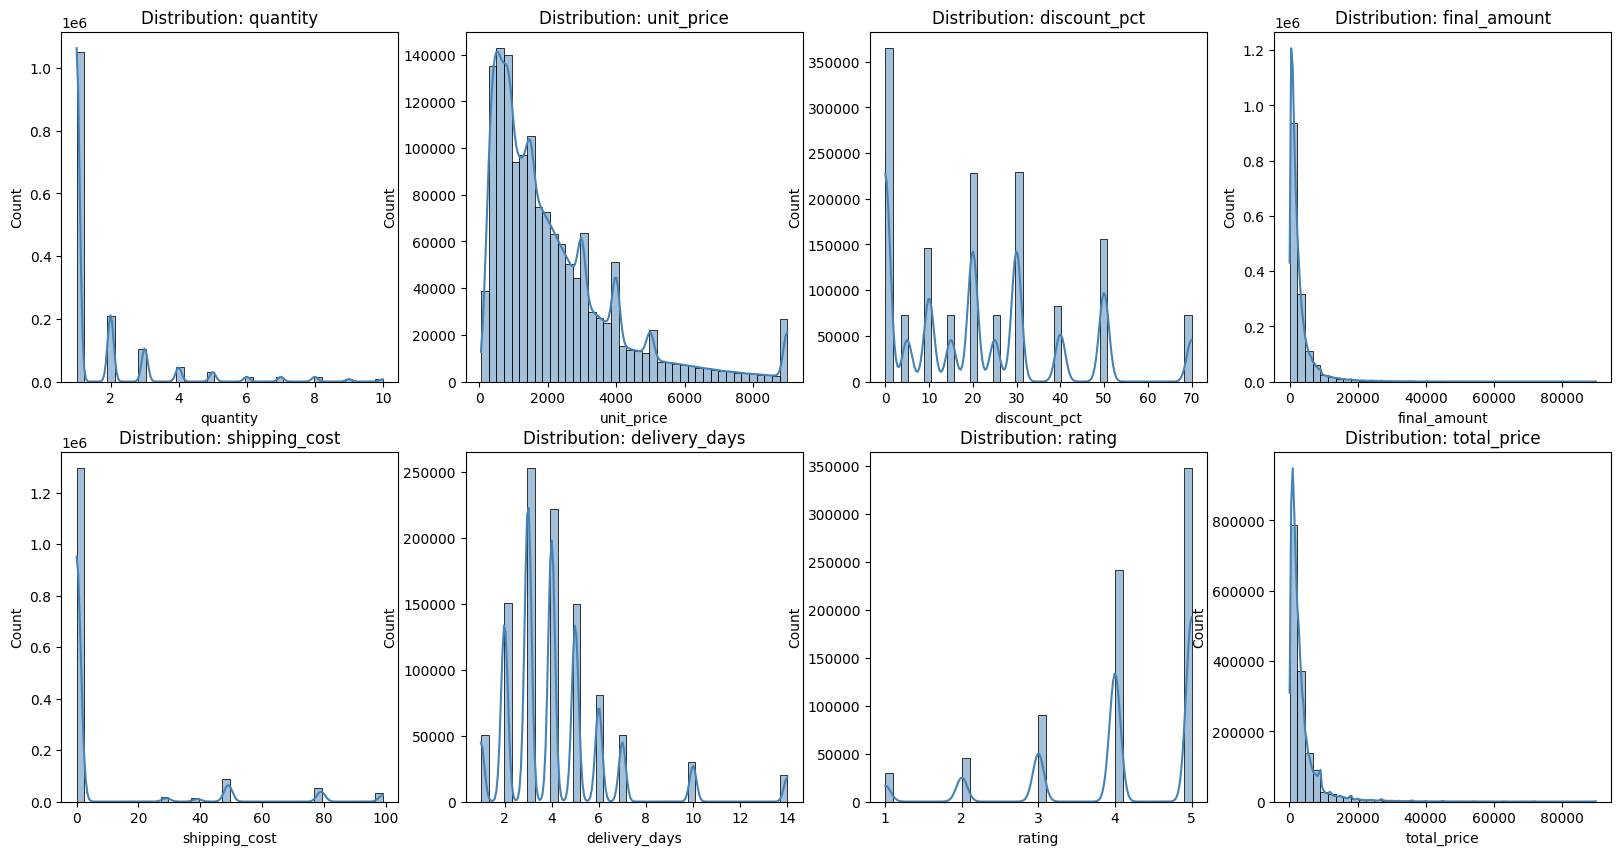

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['quantity', 'unit_price', 'discount_pct', 'final_amount', 'shipping_cost', 'delivery_days', 'rating', 
            'total_price', 'discount_amt', 'total_revenue']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # convert 2D array of axes into 1D so we can loop

for i, col in enumerate(num_cols):
    sns.histplot(data=df_cleaned, x=col, bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Columns — Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

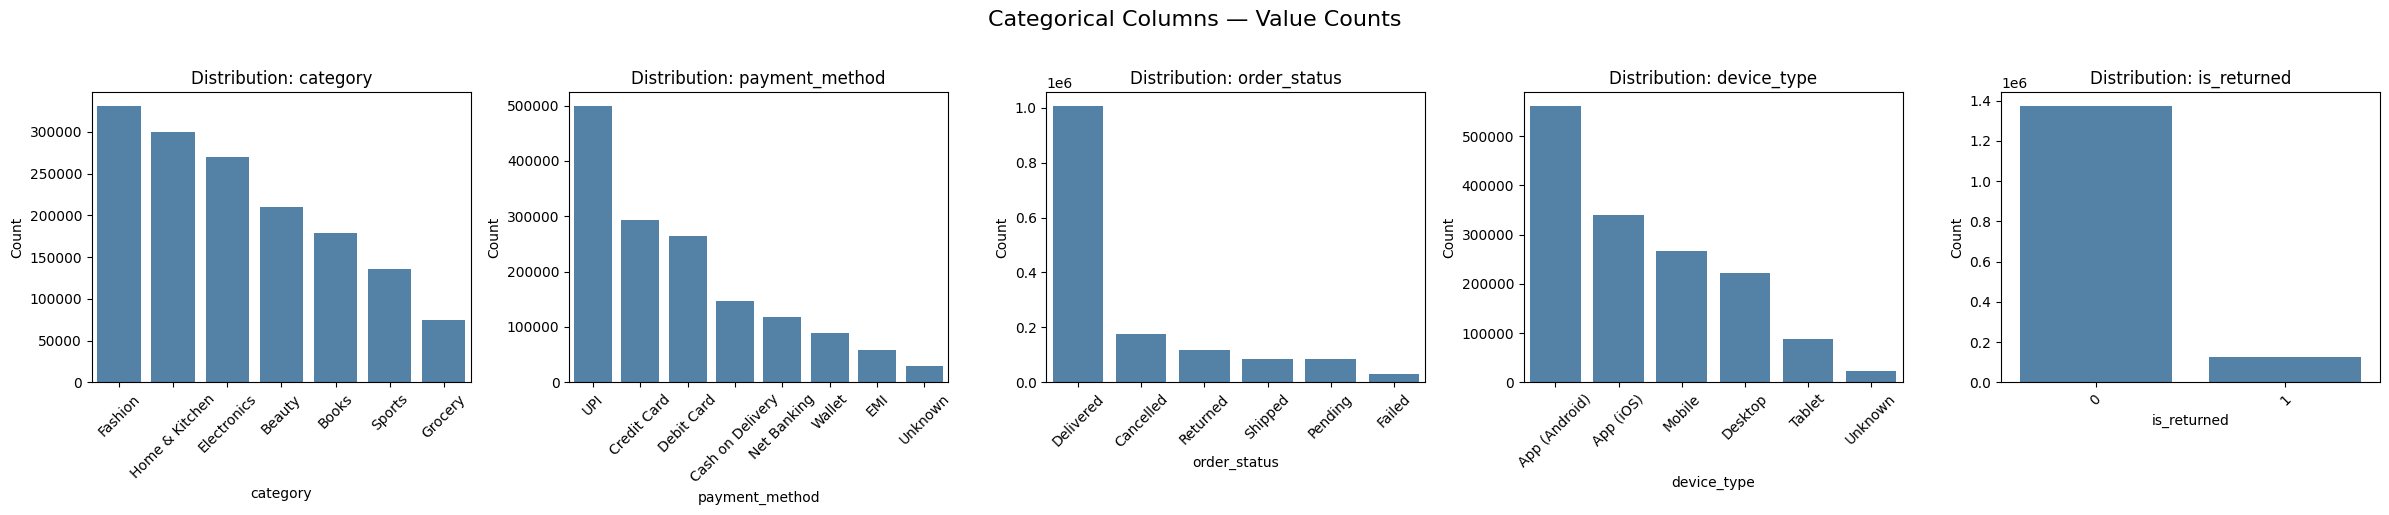

In [24]:
cat_cols = ['category', 'payment_method', 'order_status', 'device_type', 'is_returned']

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(24, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_cleaned[col].value_counts().index  # sort bars by frequency
    sns.countplot(data=df_cleaned, x=col, ax=axes[i], order=order, color='steelblue')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # rotate labels so they don't overlap

plt.suptitle('Categorical Columns — Value Counts', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
df_cleaned.duplicated(subset='order_id').sum()

np.int64(0)